# From cubes to visibilities

Interferometers do not observe images — they sample the Fourier transform
of the sky at discrete (u, v) baselines. `VisibilityCubePadded` turns any
SuperMAGE cube simulator into a model for **gridded** visibilities:

1. multiply the cube by the **primary beam** (the antenna's sensitivity
   pattern);
2. normalize the cube to a total line **flux** (a fit parameter, Jy km/s);
3. zero-**pad** the image to the uv-grid size (padding in the image plane =
   finer sampling in the uv plane);
4. multiply by the **image-plane taper** of the gridding kernel (so the
   model matches kernel-weighted-mean gridded data, e.g. from
   [viscube](https://github.com/mjyb16/viscube));
5. **FFT** each channel and apply the **uv mask** of cells that actually
   contain data.

```{important}
All frequencies in this module are in **Hz** — a value that looks like GHz
raises immediately. (A GHz frequency once made the primary beam silently
flat; the loud check is the fix.)
```

In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib import colors

from supermage.simulators.intensity_models import ExponentialDisk2D
from supermage.simulators.velocity_models import SersicMGE
from supermage.simulators.analytic_cube import AnalyticInverse
from supermage.simulators.visibility_cube import VisibilityCubePadded
from supermage.utils.primary_beams import gaussian_pb
from supermage.utils.doppler_velocities import create_velocity_grid_stable
from supermage.utils.plotting import (
    dirty_cube_tool, velocity_map,
    rotate_spectral_cube_center_offset_arcsec, create_pvd,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.float32

line_hz = 230.538e9
c_kms = 299792.458
n_chan = 30
df = line_hz * (700.0 / c_kms) / (n_chan - 1)
freqs = line_hz + (np.arange(n_chan) - (n_chan - 1) / 2) * df

velocities, _ = create_velocity_grid_stable(freqs[0], freqs[-1], n_chan,
                                            target_dtype=dtype, device=device,
                                            line=line_hz)
vel_np = velocities.cpu().numpy() - velocities.cpu().numpy().mean()

## 1. The source model

The same galaxy as in the [getting-started tutorial](01_getting_started.ipynb),
rendered on a 71-pixel grid. The uv grid will be 101 pixels: the extra
padding refines the uv-plane sampling. (The two sides must have the same
parity, and the image grid must not be larger than the uv grid.)

In [2]:
pixscale  = 0.1     # arcsec/pixel (same on the image and the padded grid)
n_pix_img = 71      # image (source cube) side
n_pix_uv  = 101     # padded uv-grid side

intensity_model = ExponentialDisk2D()
velocity_model  = SersicMGE(N_MGE_components=20, distance_Mpc=16.5, soft=1.0,
                            device=device, dtype=dtype)
cube_sim = AnalyticInverse(intensity_model, velocity_model, freqs,
                           pixel_scale_arcsec=pixscale, N_pix_x=n_pix_img,
                           K_vel=8, oversamp_xy=4, oversamp_v=4,
                           device=device, dtype=dtype, line=line_hz)

## 2. The primary beam

A 12-m ALMA antenna at 230 GHz has a ~26″ FWHM Gaussian response. On our
±3.5″ field it is nearly flat — but not exactly, and for larger mosaicked
or low-frequency fields it matters a lot. `dish_diameter=None` disables it
explicitly.

PB FWHM at band centre: 25.3 arcsec


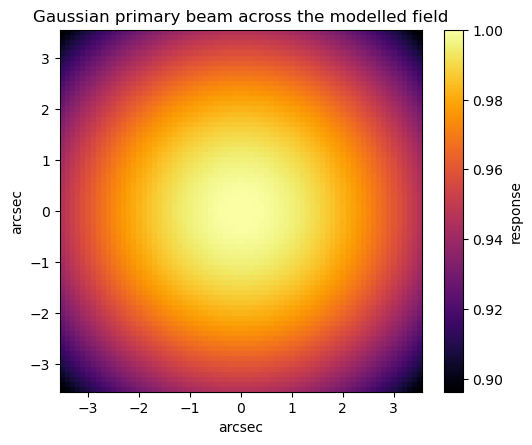

In [3]:
pb, fwhm = gaussian_pb(diameter=12.0, freq_hz=float(freqs[n_chan // 2]),
                       shape=(n_pix_img, n_pix_img), deltal=pixscale,
                       device=device, dtype=dtype)
print(f"PB FWHM at band centre: {fwhm:.1f} arcsec")

half_img = pixscale * n_pix_img / 2
plt.figure(figsize=(5.5, 4.5))
plt.imshow(pb.cpu(), origin="lower", cmap="inferno",
           extent=(-half_img, half_img, -half_img, half_img))
plt.colorbar(label="response")
plt.xlabel("arcsec"); plt.ylabel("arcsec")
plt.title("Gaussian primary beam across the modelled field")
plt.tight_layout(); plt.show()

## 3. A uv mask

With real data the mask marks which uv cells received visibilities from the
gridder. Here we mimic an interferometer with minimum and maximum baselines
by keeping an annulus of uv cells in every channel.

In [4]:
u = np.fft.fftshift(np.fft.fftfreq(n_pix_uv))   # cycles / pixel, centred
uu, vv = np.meshgrid(u, u)
r_uv = np.hypot(uu, vv)
mask2d = (r_uv > 0.03) & (r_uv < 0.42)          # min/max baseline cut
mask = np.repeat(mask2d[None], n_chan, axis=0)
print(f"uv cells kept per channel: {mask2d.sum()} / {n_pix_uv**2}")

uv cells kept per channel: 5608 / 10201


## 4. The visibility simulator

In [5]:
vis_sim = VisibilityCubePadded(
    cube_sim, mask, freqs,
    npix=n_pix_uv, pixelscale=pixscale,
    dish_diameter=12.0,     # None disables the primary beam
    line=line_hz,           # Hz!
)
print("parameters:", [p.name for p in vis_sim.dynamic_params])

parameters: ['scale', 'qintr', 'm_bh', 'n', 'r_e', 'intensity_r_e', 'inclination', 'sky_rot', 'line_broadening', 'velocity_shift', 'x0', 'y0', 'distance_pc', 'flux']


In [6]:
pars = {
    "scale": 400.0, "qintr": 0.6, "m_bh": 8.5, "n": 4.0, "r_e": 25.0,
    "intensity_r_e": 2.8, "inclination": np.deg2rad(60.0),
    "sky_rot": np.deg2rad(30.0), "line_broadening": 10.0,
    "velocity_shift": 0.0, "x0": 0.0, "y0": 0.0, "distance_pc": 16.5e6,
    "flux": 50.0,           # total line flux [Jy km/s]
}
theta = torch.tensor([pars[p.name] for p in vis_sim.dynamic_params],
                     device=device, dtype=dtype)
vis = vis_sim.forward(theta)
print("visibility cube:", tuple(vis.shape), vis.dtype)

visibility cube: (30, 101, 101) torch.complex64


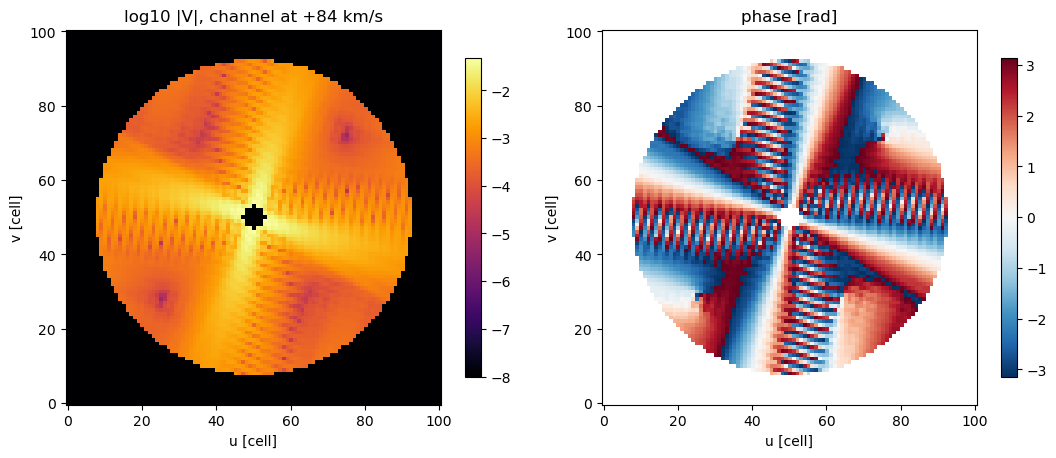

In [7]:
ch = n_chan // 2 - 4
amp = vis[ch].abs().detach().cpu().numpy()
fig, (axa, axp) = plt.subplots(1, 2, figsize=(11, 4.4))
ima = axa.imshow(np.log10(amp + 1e-8), origin="lower", cmap="inferno")
axa.set_title(f"log10 |V|, channel at {vel_np[ch]:+.0f} km/s")
fig.colorbar(ima, ax=axa, shrink=0.85)
phase = np.angle(vis[ch].detach().cpu().numpy())
phase[~mask2d] = np.nan
imp = axp.imshow(phase, origin="lower", cmap="RdBu_r", vmin=-np.pi, vmax=np.pi)
axp.set_title("phase [rad]")
fig.colorbar(imp, ax=axp, shrink=0.85)
for ax in (axa, axp):
    ax.set_xlabel("u [cell]"); ax.set_ylabel("v [cell]")
plt.tight_layout(); plt.show()

Note the Hermitian symmetry: the sky is real, so `V(-u,-v) = V*(u,v)` and
half the plane is redundant. For likelihood work you should fit only the
non-redundant half — `output_half_plane=True` returns exactly that slab
(and expects a matching half-plane mask); fitting both halves
double-counts every cell and understates posterior widths by up to √2.

## 5. Dirty images

Inverse-transforming the masked visibilities gives the *dirty cube* — the
sky convolved with the point-spread function of the uv coverage. This is
the quickest visual check that a visibility model is sensible.

dirty cube (y, x, chan): (71, 71, 30)


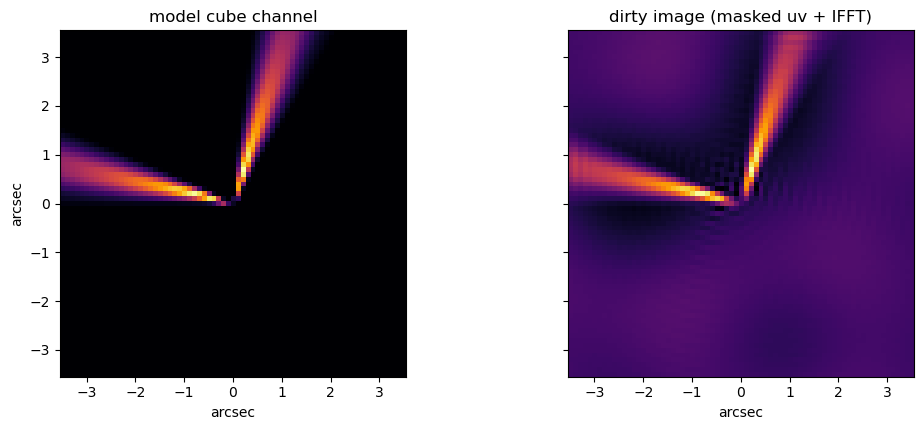

In [8]:
vis_np = vis.detach().cpu().numpy()
roi0 = (n_pix_uv - n_pix_img) // 2
dirty = dirty_cube_tool(vis_np.real, vis_np.imag, roi0, roi0 + n_pix_img)
print("dirty cube (y, x, chan):", dirty.shape)

extent_img = (-half_img, half_img, -half_img, half_img)
model_cube = cube_sim.forward(theta[:-1])   # all but the flux param

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharex=True, sharey=True)
axes[0].imshow(model_cube[ch].detach().cpu(), origin="lower", cmap="inferno",
               extent=extent_img)
axes[0].set_title("model cube channel")
axes[1].imshow(dirty[:, :, ch], origin="lower", cmap="inferno", extent=extent_img)
axes[1].set_title("dirty image (masked uv + IFFT)")
for ax in axes: ax.set_xlabel("arcsec")
axes[0].set_ylabel("arcsec")
plt.tight_layout(); plt.show()

## 6. Kinematic quick-looks: moment-1 map and PVD

The moment-1 map and the position–velocity diagram (PVD) along the major
axis are the workhorse diagnostics of disk kinematics. `create_pvd` wants
the major axis horizontal, so we first rotate the cube by the position
angle with `rotate_spectral_cube_center_offset_arcsec`.

/home/darthbarth/Code/supermage/supermage/utils/plotting.py:293: RuntimeWarning: invalid value encountered in divide
  vel_map = np.sum(cube * velocities[None, None, :], axis=2) / np.sum(cube, axis=2)


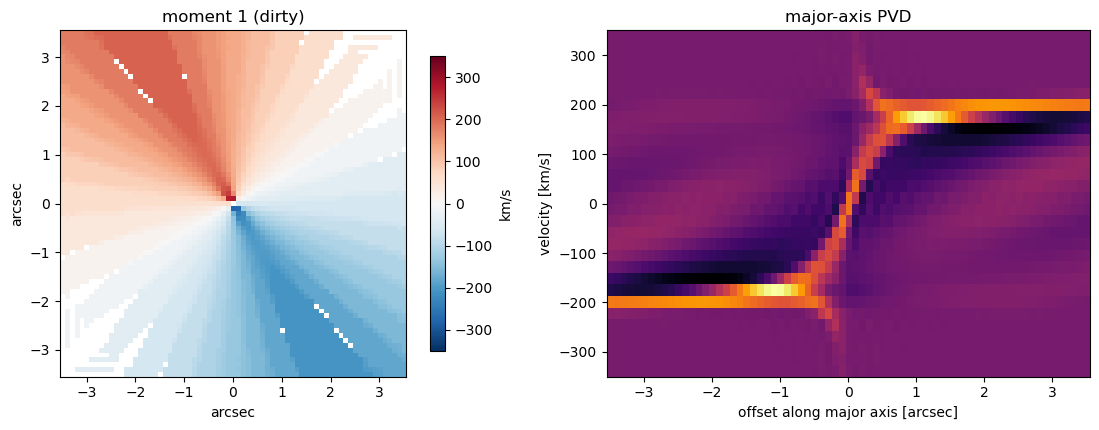

In [9]:
# Moments of *dirty* cubes need clipping: sidelobes make the
# intensity-weighted velocity meaningless wherever the per-voxel signal is
# weak. Zero everything below a threshold, then take the moment (real
# analyses build the mask from a smoothed cube — see
# supermage.utils.plotting.smooth_mask).
clip = 0.1 * dirty.max()
dirty_clipped = np.where(dirty > clip, dirty, 0.0)
mom1 = velocity_map(dirty_clipped, vel_np)
mom1 = np.where(dirty_clipped.sum(axis=2) > 0, mom1, np.nan)

rotated, extent_rot = rotate_spectral_cube_center_offset_arcsec(
    dirty, angle_deg=np.rad2deg(pars["sky_rot"]) + 90.0,
    pixel_scale=pixscale,
)
n_minor = rotated.shape[0]
pvd = create_pvd(rotated, n_minor // 2 - 3, n_minor // 2 + 4)   # 7-pixel slit

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4))
vext = np.abs(vel_np).max()          # clamp to the band's velocity range
im1 = ax1.imshow(mom1, origin="lower", cmap="RdBu_r", extent=extent_img,
                 norm=colors.TwoSlopeNorm(vcenter=0, vmin=-vext, vmax=vext))
ax1.set_title("moment 1 (dirty)")
ax1.set_xlabel("arcsec"); ax1.set_ylabel("arcsec")
fig.colorbar(im1, ax=ax1, shrink=0.85, label="km/s")

im2 = ax2.imshow(pvd, origin="lower", cmap="inferno", aspect="auto",
                 extent=(extent_rot[0], extent_rot[1], vel_np[-1], vel_np[0]))
ax2.set_title("major-axis PVD")
ax2.set_xlabel("offset along major axis [arcsec]")
ax2.set_ylabel("velocity [km/s]")
plt.tight_layout(); plt.show()

The steep central swing in the PVD — emission at large velocity right at
zero offset — is the black hole. That is the feature a black-hole fit
holds on to.

## 7. Matching real gridded data

For a real analysis, three conventions must line up between the gridder
and the model; SuperMAGE's are:

- **taper**: the model **multiplies** the image plane by the FT of the
  gridding kernel (`image_taper_map`, e.g. from `viscube`'s
  `make_kb_taper_map`), matching kernel-weighted-mean gridded
  visibilities;
- **half plane**: fit the non-redundant Hermitian slab
  (`output_half_plane=True`) so cells aren't double-counted;
- **flux and noise**: the per-cell std maps produced by the gridder become
  the Gaussian likelihood weights — see
  `supermage.utils.likelihood.load_raw_data`, which validates all of the
  above when loading a gridded `.npz`.

Fitting several datasets at once (e.g. compact + extended configurations)?
`JointVisibilityCube` runs one shared source cube through per-dataset
primary beams, tapers, masks and flux parameters.

Next: [fit this mock dataset end-to-end](05_fitting_mock_data.ipynb).